<a href="https://colab.research.google.com/github/ItsHaque/Thesis/blob/main/FL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Dataset

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Cleaning & Normalization

In [3]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_zeros]=df[cols_with_zeros].replace(0,np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Client & Dataset Sliting

In [4]:
clients = 3
indices = np.random.permutation(len(X))
client_splits = np.array_split(indices, clients)

client_data = []
for i, idx in enumerate(client_splits):
  X_train,X_test,y_train,y_test = train_test_split(X[idx],y[idx], test_size=0.2, random_state=42)
  client_data.append({
      'client_id' : i,
      'X_train' : X_train,
      'X_test' : X_test,
      'y_train' : y_train,
      'y_test' : y_test
      })
  print(f"Hospital {i+1}: train: {len(X_train)} test: {len(X_test)} positiverate: {y_train.mean():.2f}")

Hospital 1: train: 204 test: 52 positiverate: 0.32
Hospital 2: train: 204 test: 52 positiverate: 0.37
Hospital 3: train: 204 test: 52 positiverate: 0.36


# Client Visualization

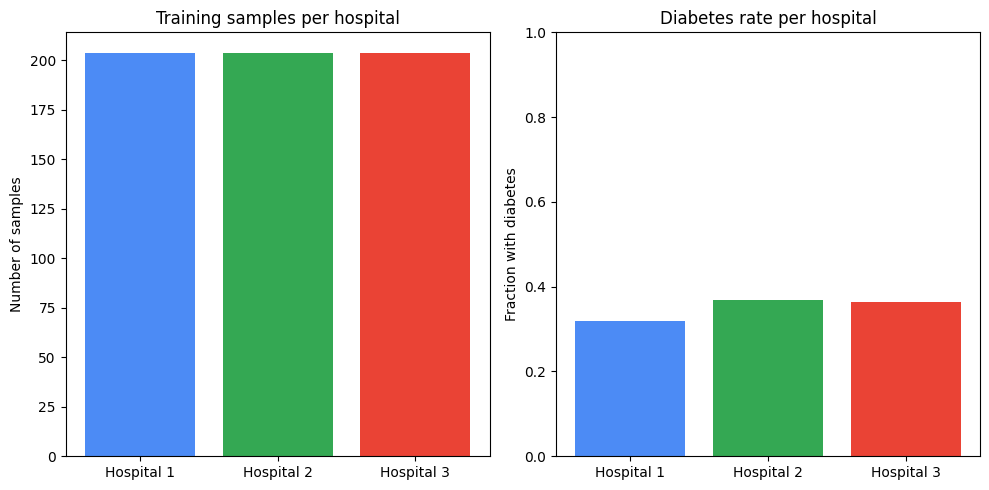

In [5]:
labels = [f"Hospital {c['client_id']+1}" for c in client_data]
train_sizes = [len(c['X_train']) for c in client_data]
pos_rates = [c['y_train'].mean() for c in client_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.bar(labels, train_sizes, color=["#4C8BF5", "#34A853", "#EA4335"])
ax1.set_title("Training samples per hospital")
ax1.set_ylabel("Number of samples")

ax2.bar(labels, pos_rates, color=["#4C8BF5", "#34A853", "#EA4335"])
ax2.set_title("Diabetes rate per hospital")
ax2.set_ylabel("Fraction with diabetes")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Model Building

In [6]:
import torch
import torch.nn as nn

class DiabetesModel(nn.Module):
  def __init__(self):
    super(DiabetesModel, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(16,8),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(8,1),
    )
  def forward(self,x):
    return self.net(x)

model = DiabetesModel()
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")


DiabetesModel(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total trainable parameters: 289


# Local Training Method Definition

In [7]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def train_local(model, client, epochs =10, lr =0.01):
  """Train the model on a single client's local data."""

  X_train = torch.tensor(client['X_train'], dtype=torch.float32)
  y_train = torch.tensor(client['y_train'], dtype=torch.float32).unsqueeze(1)

  dataset = TensorDataset(X_train, y_train)
  loader = DataLoader(dataset, batch_size=32, shuffle=True)

  pos_weight = torch.tensor([101/55])
  criterion = nn.BCEWithLogitsLoss(pos_weight= pos_weight)
  optimizer = optim.Adam(model.parameters(), lr=lr)

  model.train()
  for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in loader:
      optimizer.zero_grad()
      preds = model(batch_X)
      loss = criterion(preds, batch_y)
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()

    avg_loss = epoch_loss/len(loader)

  # print(f" Hospital {client['client_id']+1} -> final loss: {avg_loss:.4f}")

  return model.state_dict()

# Testing For a Client

In [8]:
import copy

global_model = DiabetesModel()

local_weights = train_local(copy.deepcopy(global_model), client_data[0], epochs = 10)
print("\nLocal weights returned successfully")
print(f"weight keys: {list(local_weights.keys())}")


Local weights returned successfully
weight keys: ['net.0.weight', 'net.0.bias', 'net.3.weight', 'net.3.bias', 'net.6.weight', 'net.6.bias']


#FedAvg Method Definition

In [9]:
import copy

def federated_average(global_model, local_weights_list, client_sizes):
  """Average the local weights weighted by each client's database size."""
  total_samples = sum(client_sizes)
  avg_weights = copy.deepcopy(local_weights_list[0])

  for key in avg_weights.keys():
    avg_weights[key] = torch.zeros_like(avg_weights[key])

    for i, local_weights in enumerate(local_weights_list):
      weight = client_sizes[i] / total_samples
      avg_weights[key] += weight * local_weights[key]

  global_model.load_state_dict(avg_weights)
  return global_model

# Core FL Training

In [14]:
NUM_ROUNDS = 150
EPOCHS     = 20
LR         = 0.001

global_model = DiabetesModel()
round_losses = []

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n── Round {round_num}/{NUM_ROUNDS} ──")

    local_weights_list = []
    client_sizes       = []

    # Each hospital trains locally
    for client in client_data:
        local_model   = copy.deepcopy(global_model)
        local_weights = train_local(local_model, client, epochs=EPOCHS, lr=LR)
        local_weights_list.append(local_weights)
        client_sizes.append(len(client["X_train"]))

    # Server aggregates
    global_model = federated_average(global_model, local_weights_list, client_sizes)
    # print(f"  Server aggregated weights from {len(client_data)} hospitals")


── Round 1/150 ──

── Round 2/150 ──

── Round 3/150 ──

── Round 4/150 ──

── Round 5/150 ──

── Round 6/150 ──

── Round 7/150 ──

── Round 8/150 ──

── Round 9/150 ──

── Round 10/150 ──

── Round 11/150 ──

── Round 12/150 ──

── Round 13/150 ──

── Round 14/150 ──

── Round 15/150 ──

── Round 16/150 ──

── Round 17/150 ──

── Round 18/150 ──

── Round 19/150 ──

── Round 20/150 ──

── Round 21/150 ──

── Round 22/150 ──

── Round 23/150 ──

── Round 24/150 ──

── Round 25/150 ──

── Round 26/150 ──

── Round 27/150 ──

── Round 28/150 ──

── Round 29/150 ──

── Round 30/150 ──

── Round 31/150 ──

── Round 32/150 ──

── Round 33/150 ──

── Round 34/150 ──

── Round 35/150 ──

── Round 36/150 ──

── Round 37/150 ──

── Round 38/150 ──

── Round 39/150 ──

── Round 40/150 ──

── Round 41/150 ──

── Round 42/150 ──

── Round 43/150 ──

── Round 44/150 ──

── Round 45/150 ──

── Round 46/150 ──

── Round 47/150 ──

── Round 48/150 ──

── Round 49/150 ──

── Round 50/150 ──

── Round

# Evaluation

In [17]:
from sklearn.metrics import accuracy_score, classification_report

global_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for client in client_data:
    X_test = torch.tensor(client['X_test'], dtype=torch.float32)
    y_test = client['y_test']

    preds = global_model(X_test).squeeze().numpy()
    preds_binary = (preds >= 0.5).astype(int)

    all_preds.extend(preds_binary)
    all_labels.extend(y_test)

print(f"--- Final Global Model Performance ---")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.2f}")
print(f'\nDetailed Report')
print(classification_report(all_labels, all_preds, target_names = ['No Diabetes', 'Diabetes']))


--- Final Global Model Performance ---
Accuracy: 0.74

Detailed Report
              precision    recall  f1-score   support

 No Diabetes       0.80      0.79      0.80       102
    Diabetes       0.62      0.63      0.62        54

    accuracy                           0.74       156
   macro avg       0.71      0.71      0.71       156
weighted avg       0.74      0.74      0.74       156



# Visualization

Round 01 → Accuracy: 0.7051
Round 02 → Accuracy: 0.7756
Round 03 → Accuracy: 0.7692
Round 04 → Accuracy: 0.7756
Round 05 → Accuracy: 0.7885
Round 06 → Accuracy: 0.7821
Round 07 → Accuracy: 0.7821
Round 08 → Accuracy: 0.7756
Round 09 → Accuracy: 0.7628
Round 10 → Accuracy: 0.7628
Round 11 → Accuracy: 0.7564
Round 12 → Accuracy: 0.7564
Round 13 → Accuracy: 0.7692
Round 14 → Accuracy: 0.7756
Round 15 → Accuracy: 0.7756
Round 16 → Accuracy: 0.7756
Round 17 → Accuracy: 0.7821
Round 18 → Accuracy: 0.7756
Round 19 → Accuracy: 0.7756
Round 20 → Accuracy: 0.7756
Round 21 → Accuracy: 0.7756
Round 22 → Accuracy: 0.7756
Round 23 → Accuracy: 0.7885
Round 24 → Accuracy: 0.7756
Round 25 → Accuracy: 0.7692
Round 26 → Accuracy: 0.7692
Round 27 → Accuracy: 0.7628
Round 28 → Accuracy: 0.7564
Round 29 → Accuracy: 0.7500
Round 30 → Accuracy: 0.7564
Round 31 → Accuracy: 0.7628
Round 32 → Accuracy: 0.7692
Round 33 → Accuracy: 0.7564
Round 34 → Accuracy: 0.7564
Round 35 → Accuracy: 0.7564
Round 36 → Accuracy:

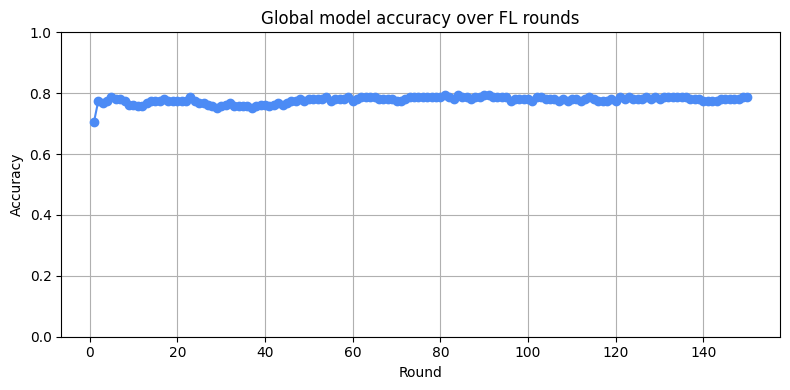

In [18]:
global_model = DiabetesModel()
round_accuracies = []

for round_num in range(1, NUM_ROUNDS + 1):
    local_weights_list = []
    client_sizes       = []

    for client in client_data:
        local_model   = copy.deepcopy(global_model)
        local_weights = train_local(local_model, client, epochs=EPOCHS, lr=LR)
        local_weights_list.append(local_weights)
        client_sizes.append(len(client["X_train"]))

    global_model = federated_average(global_model, local_weights_list, client_sizes)

    # Evaluate after each round
    global_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for client in client_data:
            X_test = torch.tensor(client["X_test"], dtype=torch.float32)
            preds  = global_model(X_test).squeeze().numpy()
            all_preds.extend((preds >= 0.5).astype(int))
            all_labels.extend(client["y_test"])

    acc = accuracy_score(all_labels, all_preds)
    round_accuracies.append(acc)
    print(f"Round {round_num:02d} → Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_ROUNDS + 1), round_accuracies, marker="o", color="#4C8BF5")
plt.title("Global model accuracy over FL rounds")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

### Feature Importance - Correlation Heatmap

To understand the relationship between features and the target variable, as well as the relationships among features, we can use a correlation heatmap. This helps in identifying potentially important features for predicting diabetes and checking for multicollinearity.

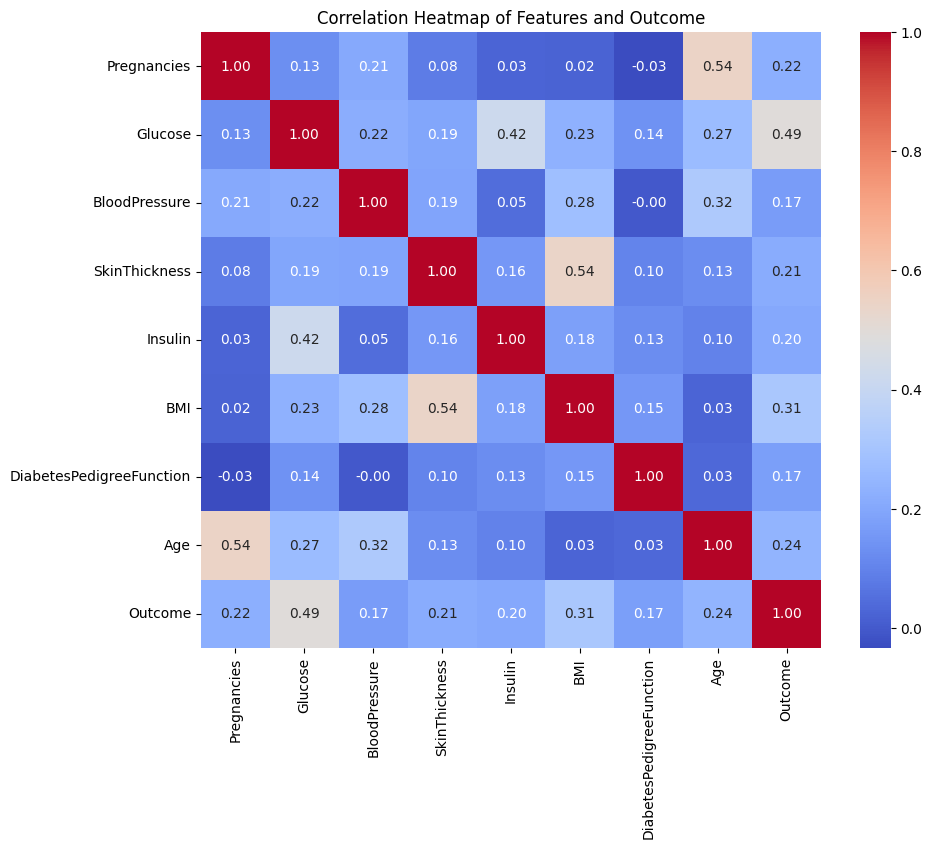

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the original DataFrame
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features and Outcome')
plt.show()

In [19]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

# Re-run evaluation to get probability scores for ROC-AUC
global_model.eval()
all_probs = []
all_labels_auc = []

with torch.no_grad():
    for client in client_data:
        X_test = torch.tensor(client['X_test'], dtype=torch.float32)
        y_test = client['y_test']

        logits = global_model(X_test).squeeze()
        probs = torch.sigmoid(logits).numpy()

        all_probs.extend(probs)
        all_labels_auc.extend(y_test)

roc_auc = roc_auc_score(all_labels_auc, all_probs)
print(f"ROC-AUC Score for Global Model: {roc_auc:.4f}")

ROC-AUC Score for Global Model: 0.8454


### Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions versus the actual outcomes, showing true positives, true negatives, false positives, and false negatives.

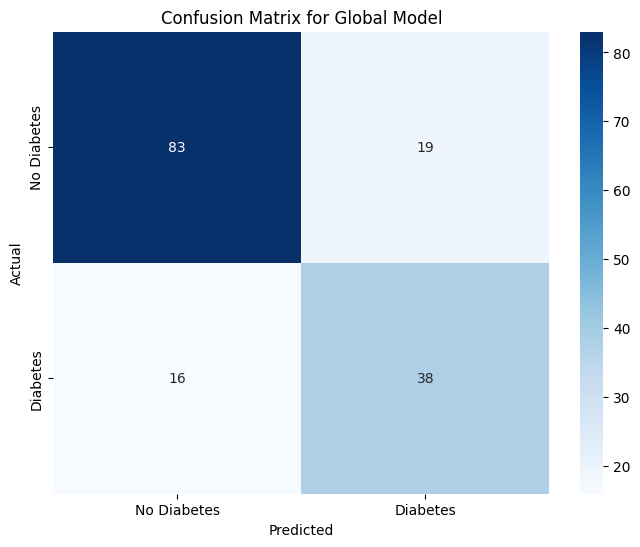

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Global Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()